In [1]:
import numpy as np
import seaborn as sns
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter
from datetime import datetime

In [ ]:
# force 'normal' text style for math text
mpl.rcParams['mathtext.default'] = 'regular'

# set global seaborn params
sns.set("paper", "ticks", color_codes=True, palette='colorblind')

## Loading Data

In [ ]:
ts = pd.read_csv('MOD-00683.csv')
COLS_TO_INCLUDE = ['timestamp_local','bin0','bin1','bin2','bin3','bin4','bin5','pm25','co','o3','no','no2','rh','temp']
ts = ts[COLS_TO_INCLUDE]
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-29T11:55:02Z,42.941,17.835,6.328,1.280,0.876,0.303,7.536,NaN,NaN,NaN,NaN,96.3,8.8
1,2025-12-29T11:54:02Z,41.879,16.737,5.744,1.112,0.770,0.244,8.294,NaN,NaN,NaN,NaN,96.0,8.8
2,2025-12-29T11:53:02Z,42.907,16.337,6.045,1.202,0.752,0.219,7.290,NaN,NaN,NaN,NaN,95.6,8.8
3,2025-12-29T11:35:06Z,36.847,14.615,5.084,1.031,0.690,0.284,6.558,NaN,NaN,NaN,NaN,94.9,8.6
4,2025-12-29T11:34:06Z,35.261,13.451,5.089,0.894,0.498,0.182,8.418,NaN,NaN,NaN,NaN,94.7,8.5


In [ ]:
ts['timestamp_local'] = pd.to_datetime(ts['timestamp_local'],format="%Y-%m-%dT%H:%M:%SZ") #convert timestamp column to pandas timestamp format
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-29 11:55:02,42.941,17.835,6.328,1.280,0.876,0.303,7.536,NaN,NaN,NaN,NaN,96.3,8.8
1,2025-12-29 11:54:02,41.879,16.737,5.744,1.112,0.770,0.244,8.294,NaN,NaN,NaN,NaN,96.0,8.8
2,2025-12-29 11:53:02,42.907,16.337,6.045,1.202,0.752,0.219,7.290,NaN,NaN,NaN,NaN,95.6,8.8
3,2025-12-29 11:35:06,36.847,14.615,5.084,1.031,0.690,0.284,6.558,NaN,NaN,NaN,NaN,94.9,8.6
4,2025-12-29 11:34:06,35.261,13.451,5.089,0.894,0.498,0.182,8.418,NaN,NaN,NaN,NaN,94.7,8.5


## Full Timeseries Plot

In [ ]:
#taking daily average of ts. round to floor of the day
ts_day = ts.groupby(ts['timestamp_local'].dt.floor('d')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_day = ts_day.set_index('timestamp_local')
ts_day.head()

C:\Users\alexa\AppData\Local\Temp\ipykernel_17004\1732368495.py:2: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  ts_day = ts.groupby(ts['timestamp_local'].dt.floor('d')).agg(bin0 = ('bin0','mean'),


,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-04-15,2.625027,0.302952,0.119215,0.033442,0.048540,0.033744,5.388944,760.058277,59.020083,2.451980,17.703737,35.317241,17.787533
2025-04-16,0.840658,0.090576,0.030162,0.006452,0.008266,0.005517,0.495880,726.209739,52.386164,2.143281,15.912844,38.811111,10.336458
2025-04-17,2.574542,0.259308,0.093874,0.022390,0.028447,0.018033,3.291242,779.538718,54.347578,2.147835,18.649936,30.430764,14.200417
2025-04-18,7.015260,1.175359,0.531528,0.158738,0.201063,0.146458,11.160694,945.526915,50.311835,9.476236,28.108258,36.153472,15.887292
2025-04-19,11.997442,1.266906,0.563967,0.186564,0.255871,0.202708,25.792534,825.706856,54.770118,2.742736,20.201353,49.177292,23.107083


In [ ]:
ts_day['pm25_c'] = 3.491 + 0.576*ts_day['pm25'] - 0.047*ts_day['rh'] + 0.070*ts_day['temp']
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-04-15,2.625027,0.302952,0.119215,0.033442,0.048540,0.033744,5.388944,760.058277,59.020083,2.451980,17.703737,35.317241,17.787533,6.180249
2025-04-16,0.840658,0.090576,0.030162,0.006452,0.008266,0.005517,0.495880,726.209739,52.386164,2.143281,15.912844,38.811111,10.336458,2.676057
2025-04-17,2.574542,0.259308,0.093874,0.022390,0.028447,0.018033,3.291242,779.538718,54.347578,2.147835,18.649936,30.430764,14.200417,4.950538
2025-04-18,7.015260,1.175359,0.531528,0.158738,0.201063,0.146458,11.160694,945.526915,50.311835,9.476236,28.108258,36.153472,15.887292,9.332457
2025-04-19,11.997442,1.266906,0.563967,0.186564,0.255871,0.202708,25.792534,825.706856,54.770118,2.742736,20.201353,49.177292,23.107083,17.653663


<>:45: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:45: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\alexa\AppData\Local\Temp\ipykernel_17004\660647158.py:45: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=14)


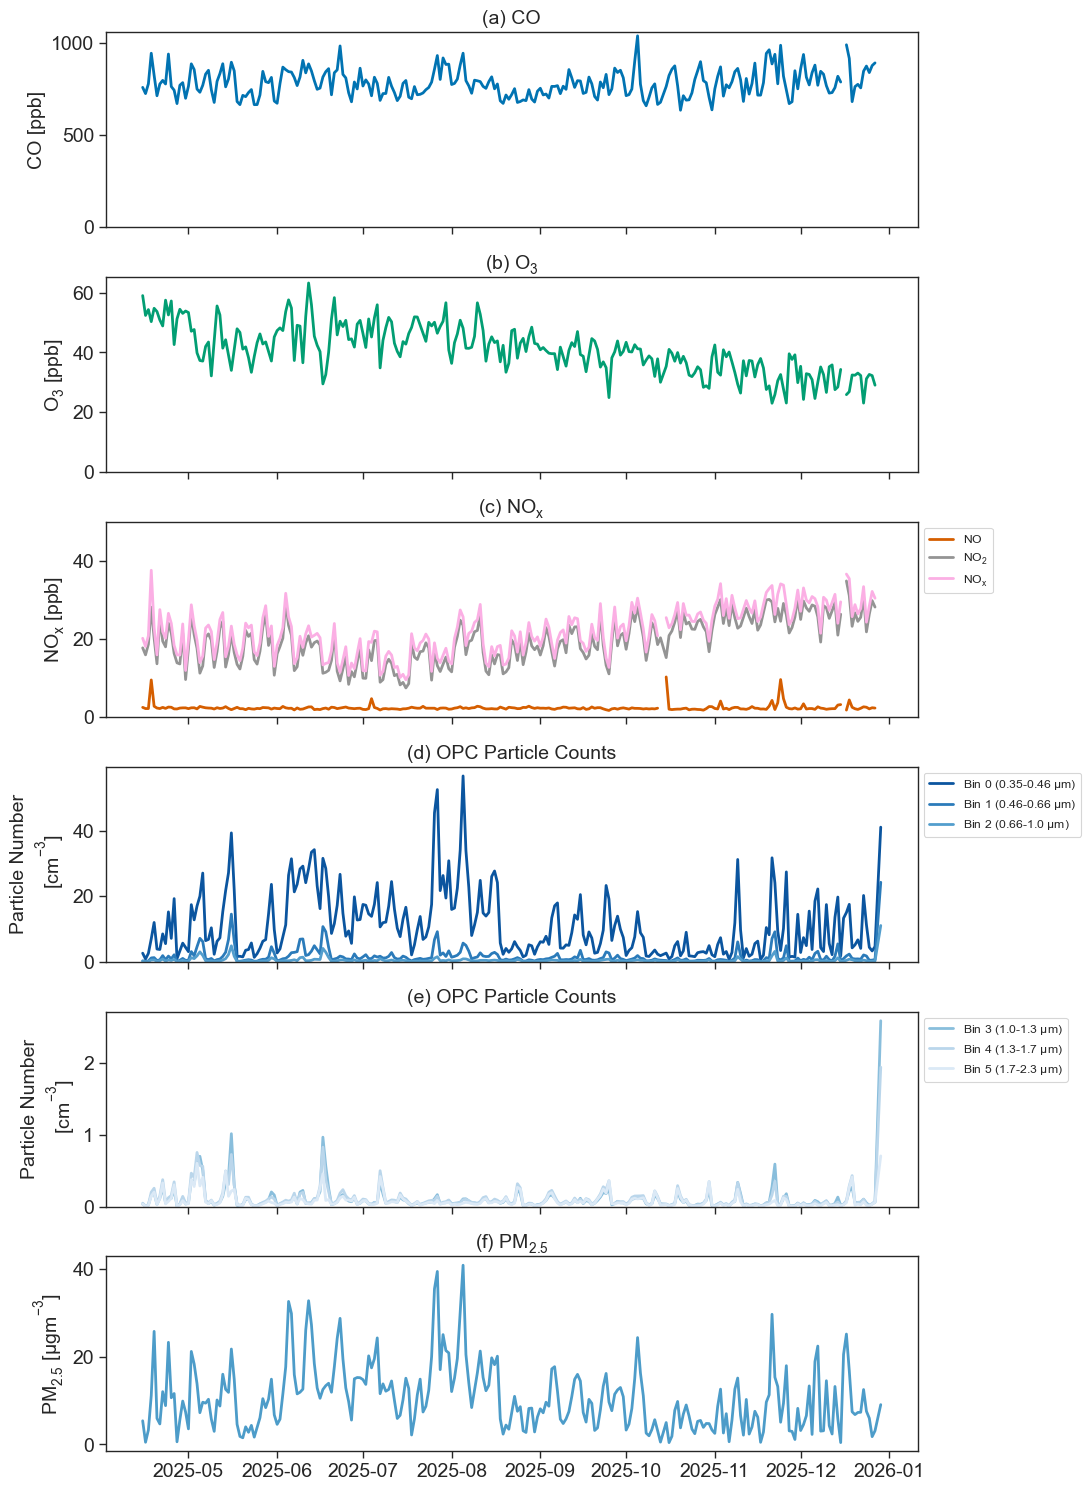

In [ ]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(ts_day['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(0, None)

# plot the o3 on the second axis
ax[1].plot(ts_day['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(0, None)

#plot nox on the 2nd axis
ax[2].plot(ts_day['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(ts_day['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(ts_day['no2']+ts_day['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 50)


# plot the OPC bins on the 5th and 6th rows
ax[3].plot(ts_day['bin0'], lw=2, label=r'Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(ts_day['bin1'], lw=2, label=r'Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(ts_day['bin2'], lw=2, label=r'Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(ts_day['bin3'], lw=2, label=r'Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(ts_day['bin4'], lw=2, label=r'Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(ts_day['bin5'], lw=2, label=r'Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(ts_day['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=14)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(d) OPC Particle Counts", fontsize=14)
ax[4].set_title("(e) OPC Particle Counts", fontsize=14)
ax[5].set_title("(f) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

# force a tight layout
plt.tight_layout()

# fig.savefig('C:/Users/alexa/Jupyter Notebook/MOD-00683/timeseries_MOD-00068.png')

## Dirunal Plots

In [ ]:
#taking daily average of ts. round to floor of the day
ts_hour = ts.groupby(ts['timestamp_local'].dt.floor('h')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_hour = ts_hour.set_index('timestamp_local')
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-04-15 08:00:00,6.545107,0.673643,0.244643,0.059393,0.062071,0.033571,12.940429,NaN,NaN,NaN,NaN,35.503571,22.582143
2025-04-15 11:00:00,16.932000,1.562833,0.473333,0.104000,0.138833,0.088167,24.384167,NaN,NaN,NaN,NaN,48.016667,20.200000
2025-04-15 12:00:00,8.521800,0.796500,0.271667,0.069967,0.098633,0.066067,16.358717,1040.323200,69.600600,2.453600,26.68740,39.053333,21.453333
2025-04-15 13:00:00,5.216883,0.516933,0.192133,0.054400,0.082200,0.058100,12.568967,948.322183,67.308917,2.925033,22.57575,32.343333,22.590000
2025-04-15 14:00:00,2.794117,0.346500,0.150567,0.049783,0.076167,0.057967,8.419617,782.325767,66.135150,2.979283,7.88715,25.741667,22.905000


In [ ]:
ts_hour['pm25_c'] = 2.111 + 0.298*ts_hour['pm25'] + 0.024*ts_hour['rh'] + 0.050*ts_hour['temp']
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-04-15 08:00:00,6.545107,0.673643,0.244643,0.059393,0.062071,0.033571,12.940429,NaN,NaN,NaN,NaN,35.503571,22.582143,7.948441
2025-04-15 11:00:00,16.932000,1.562833,0.473333,0.104000,0.138833,0.088167,24.384167,NaN,NaN,NaN,NaN,48.016667,20.200000,11.539882
2025-04-15 12:00:00,8.521800,0.796500,0.271667,0.069967,0.098633,0.066067,16.358717,1040.323200,69.600600,2.453600,26.68740,39.053333,21.453333,8.995844
2025-04-15 13:00:00,5.216883,0.516933,0.192133,0.054400,0.082200,0.058100,12.568967,948.322183,67.308917,2.925033,22.57575,32.343333,22.590000,7.762292
2025-04-15 14:00:00,2.794117,0.346500,0.150567,0.049783,0.076167,0.057967,8.419617,782.325767,66.135150,2.979283,7.88715,25.741667,22.905000,6.383096


In [ ]:
#prepping data
ts_hour['Hour'] = ts_hour.index.hour
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour
timestamp_local,,,,,,,,,,,,,,,
2025-04-15 08:00:00,6.545107,0.673643,0.244643,0.059393,0.062071,0.033571,12.940429,NaN,NaN,NaN,NaN,35.503571,22.582143,7.948441,8
2025-04-15 11:00:00,16.932000,1.562833,0.473333,0.104000,0.138833,0.088167,24.384167,NaN,NaN,NaN,NaN,48.016667,20.200000,11.539882,11
2025-04-15 12:00:00,8.521800,0.796500,0.271667,0.069967,0.098633,0.066067,16.358717,1040.323200,69.600600,2.453600,26.68740,39.053333,21.453333,8.995844,12
2025-04-15 13:00:00,5.216883,0.516933,0.192133,0.054400,0.082200,0.058100,12.568967,948.322183,67.308917,2.925033,22.57575,32.343333,22.590000,7.762292,13
2025-04-15 14:00:00,2.794117,0.346500,0.150567,0.049783,0.076167,0.057967,8.419617,782.325767,66.135150,2.979283,7.88715,25.741667,22.905000,6.383096,14


In [ ]:
#groupping by hour and calculate the mean
diurnal_data = ts_hour.groupby('Hour').mean()
diurnal_data.index = diurnal_data.index.map(lambda x: "{:02d}:00".format(x))
diurnal_data

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
Hour,,,,,,,,,,,,,,
00:00,11.847832,2.095076,0.635284,0.138316,0.138034,0.093247,11.099114,807.606886,38.811966,2.364213,21.334984,62.452089,17.554400,7.795106
01:00,11.780521,1.948697,0.552990,0.117673,0.123316,0.089365,10.650798,791.123457,38.125814,2.190507,21.562256,63.906365,17.319529,7.684667
02:00,11.691173,1.829003,0.512623,0.112412,0.121532,0.090933,10.195731,780.295410,37.276670,2.102664,21.028744,65.353463,16.940689,7.564845
03:00,11.758922,1.864151,0.519628,0.115109,0.124893,0.093537,10.047924,774.456315,36.359174,2.042466,20.432681,66.417145,16.673697,7.532978
04:00,11.858092,1.931857,0.545216,0.122140,0.129801,0.094644,9.863277,773.512517,35.442529,2.014397,20.687040,67.603143,16.469971,7.496231
05:00,12.305724,2.041120,0.581388,0.131375,0.138868,0.099843,9.824496,782.965187,34.032882,2.142684,21.082182,68.806820,16.346203,7.507374
06:00,11.975803,1.876385,0.537468,0.123088,0.132963,0.097934,9.844135,803.896459,32.590861,2.171960,21.970709,68.482088,15.990744,7.487659
07:00,12.007610,1.825097,0.536188,0.125105,0.136697,0.100781,10.333238,816.678230,32.100455,2.868068,20.577978,64.984179,16.970477,7.598449
08:00,11.583721,1.604650,0.438227,0.097673,0.113956,0.088166,10.578525,804.569277,33.208697,2.853043,18.336411,59.256163,18.722635,7.621680


<>:26: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:27: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:28: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:34: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:35: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:36: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:26: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences wil

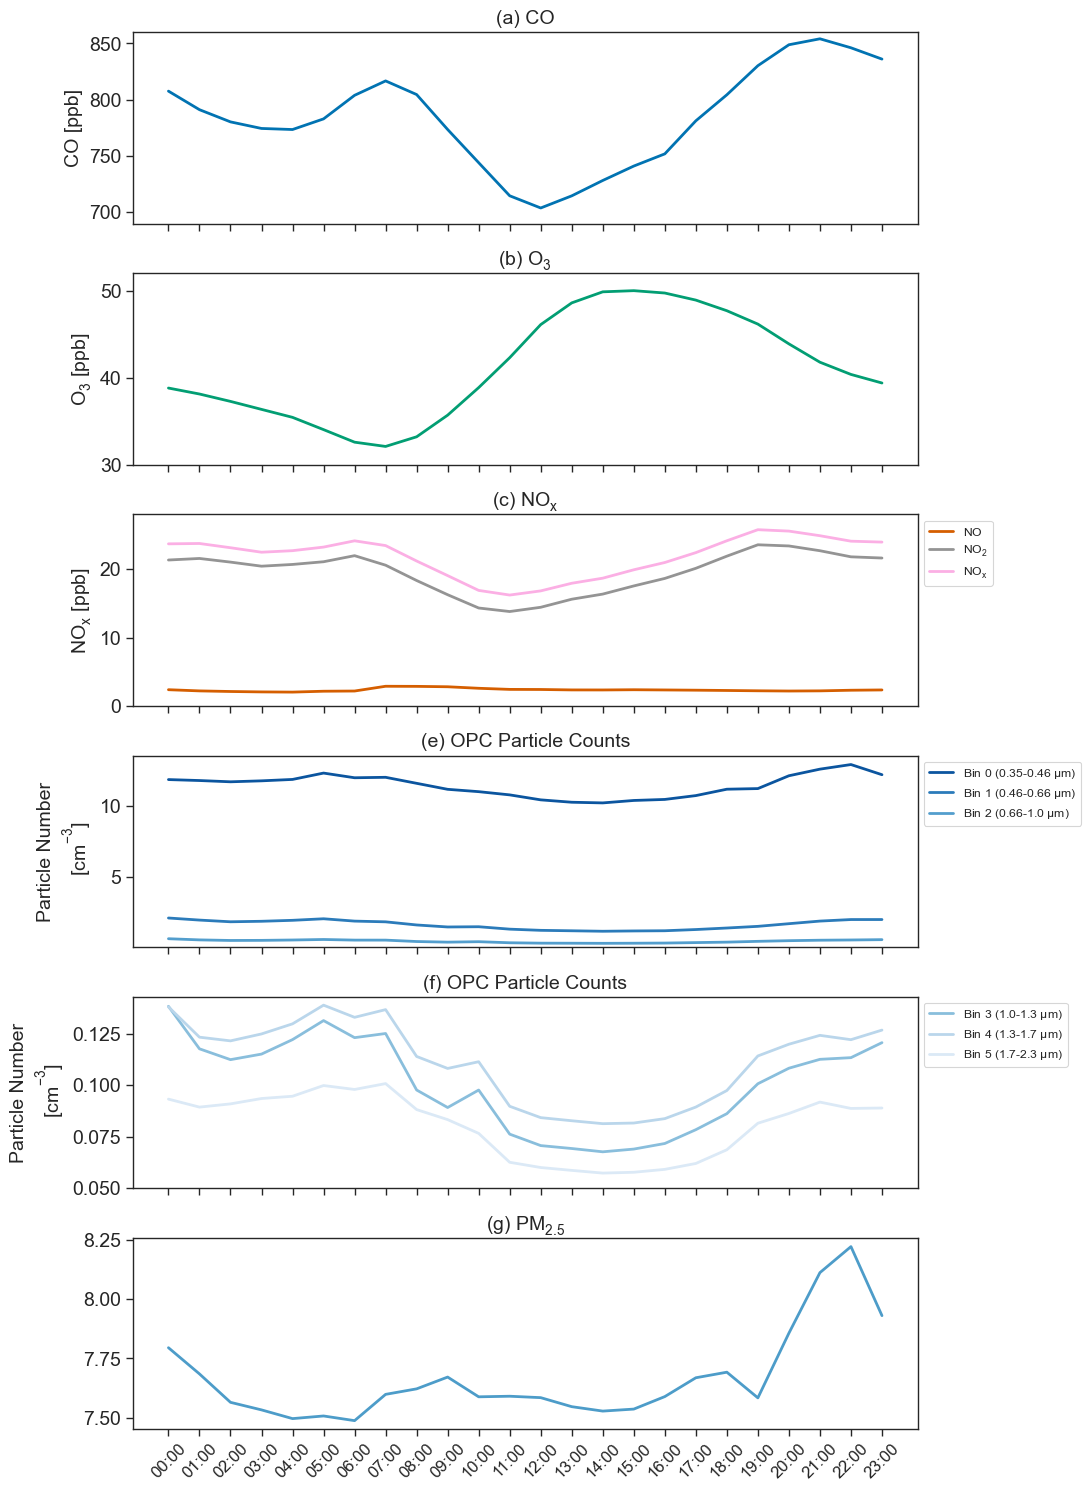

In [ ]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(diurnal_data['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(690, 860)

# plot the o3 on the first axis
ax[1].plot(diurnal_data['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(30, 52)

#plot nox on the 2nd axis
ax[2].plot(diurnal_data['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(diurnal_data['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(diurnal_data['no2']+diurnal_data['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 28)

# plot the OPC bins on the 3rd and 4th rows
ax[3].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(diurnal_data['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0.05, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(diurnal_data['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(diurnal_data['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(diurnal_data['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0.05, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(diurnal_data['pm25_c'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(e) OPC Particle Counts", fontsize=14)
ax[4].set_title("(f) OPC Particle Counts", fontsize=14)
ax[5].set_title("(g) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# set x as hours
ax[5].set_xticks(range(24))
ax[5].set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

plt.xticks(range(0, 24), size = 12)
plt.xticks(rotation=45)

# force a tight layout
plt.tight_layout()

# fig.savefig('C:/Users/alexa/Jupyter Notebook/MOD-00683/dirunal_MOD-00068_allfeatures.png')

## Diurnal by Season

In [ ]:
def month_to_season(month):
    if 3 <= month <= 5:
        return 'Spring'
    elif 6 <= month <= 8:
        return 'Summer'
    elif 9 <= month <= 11:
        return 'Autumn'
    else:
        return 'Winter'

In [ ]:
ts_hour = ts_hour.reset_index()

In [ ]:
#prepping data
ts_hour['Season'] = ts_hour['timestamp_local'].dt.month.apply(month_to_season)
ts_hour.head()

,index,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour,Season
0,0,2025-04-15 08:00:00,6.545107,0.673643,0.244643,0.059393,0.062071,0.033571,12.940429,NaN,NaN,NaN,NaN,35.503571,22.582143,7.948441,8,Spring
1,1,2025-04-15 11:00:00,16.932000,1.562833,0.473333,0.104000,0.138833,0.088167,24.384167,NaN,NaN,NaN,NaN,48.016667,20.200000,11.539882,11,Spring
2,2,2025-04-15 12:00:00,8.521800,0.796500,0.271667,0.069967,0.098633,0.066067,16.358717,1040.323200,69.600600,2.453600,26.68740,39.053333,21.453333,8.995844,12,Spring
3,3,2025-04-15 13:00:00,5.216883,0.516933,0.192133,0.054400,0.082200,0.058100,12.568967,948.322183,67.308917,2.925033,22.57575,32.343333,22.590000,7.762292,13,Spring
4,4,2025-04-15 14:00:00,2.794117,0.346500,0.150567,0.049783,0.076167,0.057967,8.419617,782.325767,66.135150,2.979283,7.88715,25.741667,22.905000,6.383096,14,Spring


In [ ]:
grouped_by_season_hour = ts_hour.drop(columns='timestamp_local').groupby(['Season', 'Hour']).mean()
grouped_by_season_hour

index       bin0      bin1      bin2      bin3      bin4  \
Season Hour                                                                   
Autumn 0     4350.082353   6.953088  1.302655  0.461565  0.108140  0.110813   
       1     4335.144578   7.128763  1.108981  0.354934  0.080627  0.092400   
       2     4336.144578   7.337906  1.077796  0.341396  0.081289  0.095196   
       3     4332.426829   7.737387  1.127960  0.350008  0.084042  0.097356   
       4     4322.209877   8.245527  1.254029  0.361616  0.081153  0.090019   
...                  ...        ...       ...       ...       ...       ...   
Winter 19    5698.875000  10.147521  1.383475  0.380768  0.071068  0.071321   
       20    5699.875000  10.775781  1.535353  0.421135  0.077132  0.072801   
       21    5700.875000  10.420987  1.472835  0.394001  0.072108  0.071276   
       22    5701.875000  10.959745  1.590228  0.403458  0.075720  0.073718   
       23    5702.875000  12.172126  1.981949  0.474953  0.082510  0.081576   

                 bin5      pm25          co         o3        no        no2  \
Season Hour                                                                   
Autumn 0     0.077589  8.235482  791.747603  35.460143  2.772950  23.264445   
       1     0.075178  7.876012  788.084242  34.376866  2.337532  24.396899   
       2     0.079836  7.772374  785.176314  33.444222  2.120510  24.438893   
       3     0.082369  7.773500  778.330109  32.587938  1.981342  24.223170   
       4     0.074131  7.572389  778.088154  31.810030  1.970103  23.913296   
...               ...       ...         ...        ...       ...        ...   
Winter 19    0.047712  9.486594  827.023666  30.513491  2.158428  28.697152   
       20    0.046807  9.978380  836.616472  29.821617  2.241618  28.616468   
       21    0.048742  9.688294  847.080293  29.784221  2.172552  28.629469   
       22    0.053144  9.677298  826.380853  29.591049  2.147616  28.574596   
       23    0.059669  9.187930  820.715919  29.093694  2.269826  28.481126   

                    rh       temp    pm25_c  
Season Hour                                  
Autumn 0     60.924211  15.540398  6.804375  
       1     63.253153  15.332108  6.742733  
       2     65.123550  14.942474  6.737256  
       3     66.399380  14.652480  6.753712  
       4     67.796217  14.496527  6.719508  
...                ...        ...       ...  
Winter 19    55.485417   2.865764  6.412943  
       20    56.134583   2.607014  6.562138  
       21    56.459306   2.445764  6.475423  
       22    58.208194   2.257014  6.504682  
       23    59.968819   1.981597  6.387335  

[96 rows x 15 columns]

In [ ]:
grouped_by_season_hour = grouped_by_season_hour.reset_index()
grouped_by_season_hour

,Season,Hour,index,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
0,Autumn,0,4350.082353,6.953088,1.302655,0.461565,0.108140,0.110813,0.077589,8.235482,791.747603,35.460143,2.772950,23.264445,60.924211,15.540398,6.804375
1,Autumn,1,4335.144578,7.128763,1.108981,0.354934,0.080627,0.092400,0.075178,7.876012,788.084242,34.376866,2.337532,24.396899,63.253153,15.332108,6.742733
2,Autumn,2,4336.144578,7.337906,1.077796,0.341396,0.081289,0.095196,0.079836,7.772374,785.176314,33.444222,2.120510,24.438893,65.123550,14.942474,6.737256
3,Autumn,3,4332.426829,7.737387,1.127960,0.350008,0.084042,0.097356,0.082369,7.773500,778.330109,32.587938,1.981342,24.223170,66.399380,14.652480,6.753712
4,Autumn,4,4322.209877,8.245527,1.254029,0.361616,0.081153,0.090019,0.074131,7.572389,778.088154,31.810030,1.970103,23.913296,67.796217,14.496527,6.719508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,Winter,19,5698.875000,10.147521,1.383475,0.380768,0.071068,0.071321,0.047712,9.486594,827.023666,30.513491,2.158428,28.697152,55.485417,2.865764,6.412943
92,Winter,20,5699.875000,10.775781,1.535353,0.421135,0.077132,0.072801,0.046807,9.978380,836.616472,29.821617,2.241618,28.616468,56.134583,2.607014,6.562138
93,Winter,21,5700.875000,10.420987,1.472835,0.394001,0.072108,0.071276,0.048742,9.688294,847.080293,29.784221,2.172552,28.629469,56.459306,2.445764,6.475423
94,Winter,22,5701.875000,10.959745,1.590228,0.403458,0.075720,0.073718,0.053144,9.677298,826.380853,29.591049,2.147616,28.574596,58.208194,2.257014,6.504682


In [ ]:
autumn_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Autumn']
winter_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Winter']
spring_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Spring']
summer_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Summer']

autumn_diurnal.index = autumn_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
winter_diurnal.index = winter_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
spring_diurnal.index = spring_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
summer_diurnal.index = summer_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))

In [ ]:
autumn_diurnal

,Season,Hour,index,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
00:00,Autumn,0,4350.082353,6.953088,1.302655,0.461565,0.108140,0.110813,0.077589,8.235482,791.747603,35.460143,2.772950,23.264445,60.924211,15.540398,6.804375
01:00,Autumn,1,4335.144578,7.128763,1.108981,0.354934,0.080627,0.092400,0.075178,7.876012,788.084242,34.376866,2.337532,24.396899,63.253153,15.332108,6.742733
02:00,Autumn,2,4336.144578,7.337906,1.077796,0.341396,0.081289,0.095196,0.079836,7.772374,785.176314,33.444222,2.120510,24.438893,65.123550,14.942474,6.737256
03:00,Autumn,3,4332.426829,7.737387,1.127960,0.350008,0.084042,0.097356,0.082369,7.773500,778.330109,32.587938,1.981342,24.223170,66.399380,14.652480,6.753712
04:00,Autumn,4,4322.209877,8.245527,1.254029,0.361616,0.081153,0.090019,0.074131,7.572389,778.088154,31.810030,1.970103,23.913296,67.796217,14.496527,6.719508
05:00,Autumn,5,4311.437500,8.936274,1.470116,0.424097,0.091572,0.095700,0.074621,7.588015,785.300483,30.452013,1.972930,24.354044,69.143500,14.386896,6.751017
06:00,Autumn,6,4377.079545,8.697770,1.383798,0.397532,0.085355,0.089613,0.069633,7.463527,815.878610,28.770029,2.004414,25.176568,69.263172,13.479025,6.671399
07:00,Autumn,7,4374.483146,8.596981,1.198440,0.343976,0.076728,0.086121,0.068652,7.780305,838.513797,28.191212,2.674076,24.675652,67.830440,14.066776,6.760800
08:00,Autumn,8,4382.400000,8.033257,1.046658,0.312273,0.073608,0.088506,0.070771,8.305878,829.464339,29.452643,2.798749,21.949520,62.114808,15.535557,6.853685
09:00,Autumn,9,4383.400000,7.039599,0.937431,0.294965,0.071590,0.087139,0.068056,8.365891,781.975307,31.450438,2.977194,18.943639,55.193284,17.638969,6.810623


In [ ]:
seasons_order = [winter_diurnal, spring_diurnal, summer_diurnal, autumn_diurnal]

<>:40: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:41: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:42: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:48: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:49: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:50: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:56: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences wil

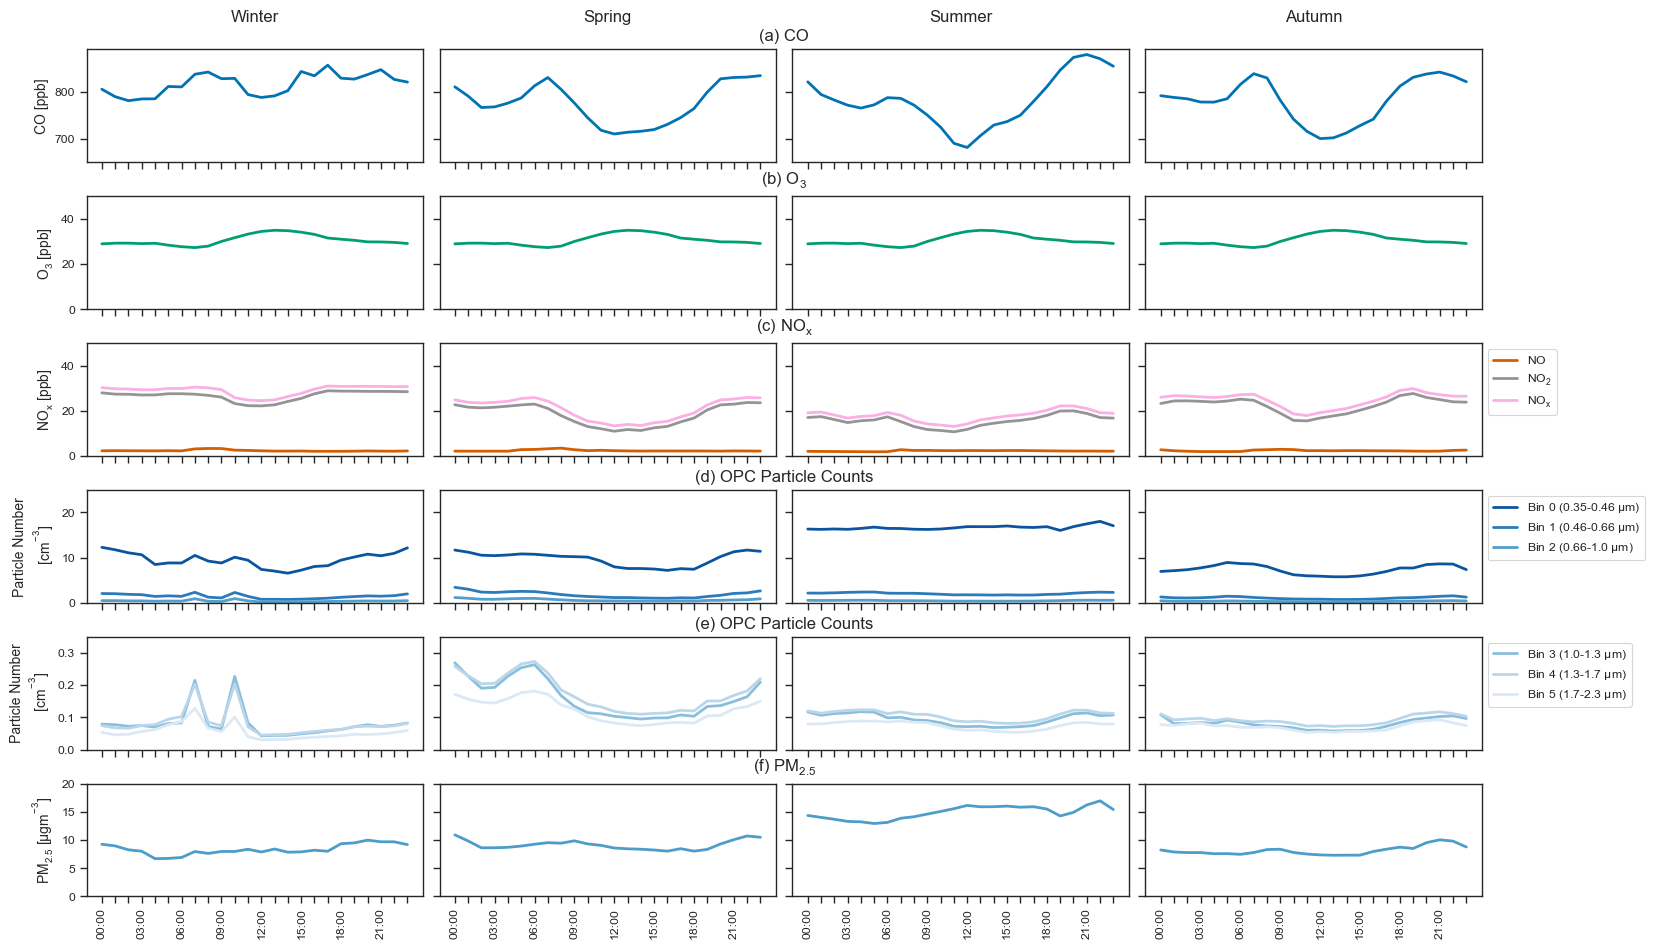

In [ ]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=4, figsize=(18,11), sharex=True)
plt.subplots_adjust(hspace = 0.3, wspace = 0.05)

# grab the current color palette
cmap = sns.color_palette()

#iterate through seasons
for i in range(len(seasons_order)):

    #set ax column labels as season
    ax[0,0].set_title("Winter", fontsize=12, pad = 20)
    ax[0,1].set_title("Spring", fontsize=12, pad = 20)
    ax[0,2].set_title("Summer", fontsize=12, pad = 20)
    ax[0,3].set_title("Autumn", fontsize=12, pad = 20)

    # plot the CO data and label the axis
    ax[0,0].set_ylabel("CO [ppb]", fontsize=10)
    ax[0,i].plot(seasons_order[i]['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
    ax[0,i].set_ylim(650, 890)
    ax[0,i].set_xticks(range(0, 2))
    ax[0,i].set_xticks(seasons_order[i].index)

    # plot the o3 on the second axis
    ax[1,0].set_ylabel("$O_3$ [ppb]", fontsize=10)
    ax[1,i].plot(winter_diurnal['o3'], lw=2, label="$O_3$", color=cmap[2])
    ax[1,i].set_ylim(0, 50)

    #plot nox on the 3rd axis
    ax[2,0].set_ylabel("$NO_x$ [ppb]", fontsize=10)
    ax[2,i].plot(seasons_order[i]['no'], lw=2, label="$NO$", color=cmap[3])
    ax[2,i].plot(seasons_order[i]['no2'], lw=2, label="$NO_2$", color=cmap[7])
    ax[2,i].plot(seasons_order[i]['no2']+seasons_order[i]['no'], lw=2, label="$NO_x$", color=cmap[6])
    ax[2,i].set_ylim(0, 50)
    ax[2,3].legend(fontsize = 14)
    sns.move_legend(ax[2,3], "upper left", bbox_to_anchor=(1, 1))

    # plot the OPC bins on the 4th and 5th rows
    ax[3,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
    ax[3,i].plot(seasons_order[i]['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
    ax[3,i].plot(seasons_order[i]['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
    ax[3,i].set(ylim=(0, 25))
    ax[3,3].legend(fontsize = 14)
    sns.move_legend(ax[3,3], "upper left", bbox_to_anchor=(1, 1))

    ax[4,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[4,i].plot(seasons_order[i]['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
    ax[4,i].plot(seasons_order[i]['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
    ax[4,i].plot(seasons_order[i]['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
    ax[4,i].set(ylim=(0, 0.35))
    ax[4,3].legend(fontsize = 14)
    sns.move_legend(ax[4,3], "upper left", bbox_to_anchor=(1, 1))

    #plot pm25 on the 6th row
    ax[5,0].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=10)
    ax[5,i].plot(seasons_order[i]['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
    ax[5,i].set(ylim=(0, 20))
    ax[5,i].set_xticklabels(['00:00','','','03:00','','','06:00','','','09:00','','','12:00','','','15:00','','','18:00','','','21:00','',''], rotation=90)

    #remove subplot y ticks for subplots beyond winter
    if i>0:
        for j in range(6):
            ax[j,i].set_yticklabels([])

    # set titles for each panel
    row_titles = [
    "(a) CO",
    "(b) $O_3$",
    "(c) $NO_x$",
    "(d) OPC Particle Counts",
    "(e) OPC Particle Counts",
    "(f) $PM_{2.5}$"
]

for r, title in enumerate(row_titles):

    # left and right subplot positions
    left = ax[r,0].get_position()
    right = ax[r,-1].get_position()

    # horizontal center between first and last column
    x_center = (left.x0 + right.x1) / 2

    # slightly above the row
    y_top = left.y1 + 0.005

    fig.text(
        x_center,
        y_top,
        title,
        ha='center',
        va='bottom',
        fontsize=12
    )

# fig.savefig('C:/Users/alexa/Jupyter Notebook/MOD-00683/diurnal_by_season_MOD-000683.png')